# 마음잇다 음성 감정분류(방식A) — 베이스모델 3종 비교 파인튜닝

wav2vec2/HuBERT 기반 5-class(기쁨/분노/슬픔/불안/중립) 음성 감정분류기를 후보 3개 베이스모델로 각각 파인튜닝하고, 검증셋 Macro F1이 가장 높은 모델을 최종 채택한다.

- 후보 모델: `hyyoka/wav2vec2-xlsr-korean-senior`, `kresnik/wav2vec2-large-xlsr-korean`, `team-lucid/hubert-base-korean`
- 데이터: `데이터셋/00 음성데이터 전처리/정리된_wav_16kHz/`의 `split_train.csv`/`split_val.csv`/`split_test.csv` (2026-08-07 버그 수정판 — train 16,253 / val 3,484 / test 3,482)
- 3개 모델 전부 **동일한 데이터·동일한 분할·동일한 기본 하이퍼파라미터**로 학습해서 공정하게 비교한다.
- 관련 문서(5개 상호 인용): `전처리 진행상황.md`, `크로스체크용_인계문서.md`, `기록 조건.md`, `음성모델 개발일지.md`, `최신현황.md` — 데이터·전처리 배경은 이 문서들 참고.

**세션 중단 대비(2026-08-08 추가)**: Colab 세션이 의도치 않게 끊기는 경우를 대비해, (1) 모델 1개가 끝날 때마다 결과를 파일로 저장하고, (2) 학습 도중에도 매 epoch마다 진행상황을 저장한다. 노트북을 처음부터 다시 실행해도 이미 끝난 모델은 건너뛰고, 학습 도중이던 모델은 마지막 저장된 epoch부터 이어서 진행한다(자세한 동작은 7·8번 섹션 참고). 배치/epoch 진행 상황은 진행률 표시줄(tqdm)로 확인할 수 있다.

**주의**: 이 노트북은 실제 GPU 환경(Colab 또는 로컬 RTX 4070 Super)에서 돌리도록 작성했고, 작성 시점(샌드박스)에는 GPU·인터넷이 없어 실제 실행 검증은 못 했다. 처음 돌릴 때는 아래 "스모크 테스트" 셀로 가장 가벼운 모델 1개·1 epoch만 먼저 확인한 뒤, 문제없으면 3개 모델 전체 학습으로 넘어가는 걸 권장한다.


In [ ]:
# ===== [입력값] Colab 환경 설정 — 이 셀만 수정하면 됩니다 =====
from google.colab import drive
drive.mount('/content/drive')

from google.colab import output as _colab_output
_colab_output.enable_custom_widget_manager()  # ipywidgets 등 서드파티 위젯 허용 -> tqdm 진행바가 위젯으로 정상 렌더링됨

import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"  # CUDA 메모리 단편화 완화(2026-08-08 OOM 대응, torch import 전에 설정해야 함)

# 실제 Drive 구조에 맞춤: 내 드라이브 > 코랩용 폴더 > 마음잇다_음성모델 > (OUTPUT / 데이터셋/정리된_wav_16kHz / 이 노트북)
DRIVE_ROOT = "/content/drive/MyDrive/코랩용 폴더/마음잇다_음성모델"
OUTPUT_DIR = f"{DRIVE_ROOT}/OUTPUT"
AUDIO_DIR  = f"{DRIVE_ROOT}/데이터셋/정리된_wav_16kHz"
# OUTPUT_DIR을 Drive 경로로 둬야 세션이 끊겨도 체크포인트·중간 저장본이 남는다(코랩 런타임 자체 디스크는 세션 종료 시 초기화됨).

_required_files = ["split_train.csv", "split_val.csv", "split_test.csv", "class_weight_train.csv"]
_missing = [f for f in _required_files if not os.path.exists(os.path.join(AUDIO_DIR, f))]
if _missing:
    raise FileNotFoundError(
        f"AUDIO_DIR={AUDIO_DIR} 에 다음 파일이 없습니다: {_missing}. "
        "정리된_wav_16kHz 폴더 전체(csv 4개+wav 파일)를 Drive의 이 경로에 업로드했는지 확인할 것."
    )

DEVICE = "cuda"
BATCH_SIZE = 4           # 2026-08-08: T4(약 15GB)에서 hyyoka_senior(large 계열) batch_size=8로 OOM 확인 -> 4로 낮춤.
                         # fp16(자동 혼합정밀도) 적용도 같이 돼 있어 4로도 8과 큰 속도차 없을 것으로 기대(미실측).
                         # 그래도 OOM 나면 2로, A100이면 8~16으로 올려도 됨.
NUM_WORKERS = 2
EPOCHS = 8
LEARNING_RATE = 3e-5
SEED = 42

os.makedirs(OUTPUT_DIR, exist_ok=True)
print("AUDIO_DIR:", AUDIO_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)


Mounted at /content/drive
AUDIO_DIR: /content/drive/MyDrive/코랩용 폴더/마음잇다_음성모델/데이터셋/정리된_wav_16kHz
OUTPUT_DIR: /content/drive/MyDrive/코랩용 폴더/마음잇다_음성모델/OUTPUT


## 0. 패키지 설치
최초 1회만 실행하면 된다. 로컬에 이미 설치돼 있으면 건너뛰어도 무방(재실행해도 안전).

`ipywidgets`/`jupyter` 업그레이드는 **로컬(VS Code Jupyter 등)에서만** 실행한다 — 로컬 환경엔 tqdm이 위젯으로 안 뜨는 문제(IProgress 경고)가 있어서 필요하지만, Colab은 자체 위젯 매니저(`enable_custom_widget_manager`)가 이미 있어서 이 업그레이드가 필요 없고, 오히려 실행할 때마다 "런타임 재시작 필요" 경고만 반복해서 뜨므로 Colab에서는 건너뛴다. 로컬에서 처음 설치했다면 **커널을 재시작**한 뒤 노트북을 다시 위에서부터 실행해야 위젯이 제대로 뜬다.

In [ ]:
try:
    import google.colab
    _in_colab = True
except ImportError:
    _in_colab = False

if not _in_colab:
    get_ipython().system('pip install -q -U ipywidgets jupyter')
else:
    print("Colab 환경 감지 -> ipywidgets/jupyter 업그레이드는 건너뜀(Colab은 자체 위젯 매니저 사용)")

get_ipython().system('pip install -q transformers accelerate torchaudio librosa soundfile scikit-learn evaluate tqdm matplotlib')


Colab 환경 감지 -> ipywidgets/jupyter 업그레이드는 건너뜀(Colab은 자체 위젯 매니저 사용)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.7 MB/s eta 0:00:00


## 1. 라이브러리 임포트 및 시드 고정
재현성을 위해 랜덤 시드를 고정한다. 진행률 표시줄(tqdm)과 그래프(matplotlib)도 여기서 준비한다.

In [ ]:
import os, json, random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchaudio
from transformers import AutoModel, AutoFeatureExtractor, get_linear_schedule_with_warmup
from sklearn.metrics import f1_score, precision_recall_fscore_support, confusion_matrix
from tqdm.auto import tqdm  # ipywidgets 설치 후엔 위젯(막대)+텍스트(x/(x+n), loss 등)가 함께 표시됨
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

def set_seed(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

set_seed(SEED)
device = torch.device(DEVICE if torch.cuda.is_available() else "cpu")
print("device:", device)

def _set_korean_font():
    # 로컬(Windows)엔 "Malgun Gothic"이 보통 기본 설치돼 있다. Colab은 기본 폰트에 한글이 없어
    # 아래 후보에 다 없으면 그래프의 한글(라벨명·제목)이 깨질 수 있다 — 이 경우 다음 셀(선택)로 나눔고딕을 설치할 것.
    candidates = ["Malgun Gothic", "NanumGothic", "AppleGothic", "NanumBarunGothic"]
    available = {f.name for f in fm.fontManager.ttflist}
    for name in candidates:
        if name in available:
            plt.rcParams["font.family"] = name
            return name
    return None

_font_used = _set_korean_font()
plt.rcParams["axes.unicode_minus"] = False
print("matplotlib 한글 폰트:", _font_used or "못 찾음 — Colab이면 아래 '(선택) Colab 한글 폰트 설치' 셀 실행 후 런타임 재시작 권장")


device: cuda
matplotlib 한글 폰트: 못 찾음 — Colab이면 아래 '(선택) Colab 한글 폰트 설치' 셀 실행 후 런타임 재시작 권장


### Colab 한글 폰트 설치 (자동 판단 — 로컬에선 자동으로 건너뜀)
Colab 기본 환경엔 한글 폰트가 없어 그래프 제목·라벨(기쁨/분노/슬픔/불안/중립 등)이 네모(□)로 깨질 수 있다. 이 셀은 위에서 이미 폰트를 찾았으면(예: 로컬의 Malgun Gothic) 아무것도 안 하고, 못 찾았을 때만 Colab인지 확인해서 Colab이면 나눔고딕을 설치한다 — 로컬에서 실행해도 에러 없이 안내 메시지만 뜨고 넘어간다.

**재시작 불필요(2026-08-08 수정)**: `addfont()`는 실행 즉시 이 세션에 적용되므로 런타임을 재시작할 필요가 없다 — 세션을 재시작하면 오히려 폰트 등록 상태가 초기화돼서 이 셀이 매번 다시 도는 것처럼 보였던 것뿐이다. 폰트 파일이 이미 설치돼 있으면(같은 런타임 안에서 재실행 시) `apt-get` 단계는 건너뛰고 빠르게 재등록만 한다.

In [ ]:
if _font_used is not None:
    print(f"이미 \'{_font_used}\' 폰트를 쓰고 있어 이 셀은 건너뜁니다.")
else:
    try:
        import google.colab  # 이 임포트가 성공하면 Colab 환경
        _nanum_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
        if not os.path.exists(_nanum_path):
            import subprocess
            subprocess.run(["apt-get", "-qq", "install", "-y", "fonts-nanum"], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
        if os.path.exists(_nanum_path):
            fm.fontManager.addfont(_nanum_path)
            plt.rcParams["font.family"] = "NanumGothic"
            print("나눔고딕 적용 완료 — 재시작 없이 이 세션에서 바로 그래프 한글이 정상적으로 나옵니다.")
        else:
            print("나눔고딕 폰트 파일을 못 찾음 — apt-get 설치가 실패했을 수 있습니다(네트워크 등 확인).")
    except ImportError:
        print("로컬 환경으로 판단됨 — 이 셀은 Colab 전용이라 여기선 아무 작업도 하지 않습니다.")
    except Exception as e:
        print(f"폰트 설치 실패: {e} — 그래프 한글이 깨질 수 있으나, 학습 자체엔 영향 없으니 계속 진행해도 됩니다.")


나눔고딕 적용 완료 — 재시작 없이 이 세션에서 바로 그래프 한글이 정상적으로 나옵니다.


## 2. 라벨 정의 및 데이터 로드
5-class 라벨 매핑과 train/val/test 분할 CSV, train split 기준 class_weight를 불러온다.
(출처: `전처리 진행상황.md` 32번 항목, `크로스체크용_인계문서.md` §4·§7)

In [ ]:
LABELS = ["기쁨", "분노", "슬픔", "불안", "중립"]
label2id = {l: i for i, l in enumerate(LABELS)}
id2label = {i: l for i, l in enumerate(LABELS)}

train_df = pd.read_csv(os.path.join(AUDIO_DIR, "split_train.csv"))
val_df   = pd.read_csv(os.path.join(AUDIO_DIR, "split_val.csv"))
test_df  = pd.read_csv(os.path.join(AUDIO_DIR, "split_test.csv"))
print(f"train {len(train_df)} / val {len(val_df)} / test {len(test_df)}")

cw_df = pd.read_csv(os.path.join(AUDIO_DIR, "class_weight_train.csv"))
class_weight_map = dict(zip(cw_df["최종라벨"], cw_df["class_weight"]))
class_weights = torch.tensor([class_weight_map[l] for l in LABELS], dtype=torch.float)
print("class_weight:", dict(zip(LABELS, class_weights.tolist())))


train 16253 / val 3484 / test 3482
class_weight: {'기쁨': 1.8844000101089478, '분노': 0.9532999992370605, '슬픔': 0.3862000107765198, '불안': 2.785399913787842, '중립': 2.11899995803833}


## 3. PyTorch Dataset 정의
오디오 파일을 로드해서 파형(waveform)만 반환한다 — 정규화 등 실제 피처 추출은 모델마다 방식이 달라 collate_fn 단계에서 처리한다.

In [ ]:
class VoiceEmotionDataset(Dataset):
    def __init__(self, df, audio_dir):
        self.df = df.reset_index(drop=True)
        self.audio_dir = audio_dir

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        wav_path = os.path.join(self.audio_dir, f"{row['clean_id']}.wav")
        waveform, sr = torchaudio.load(wav_path)
        if waveform.shape[0] > 1:
            waveform = waveform.mean(dim=0, keepdim=True)  # mono 보장(이미 mono지만 방어적으로)
        assert sr == 16000, f"예상과 다른 샘플레이트: {sr} ({wav_path})"
        label_id = label2id[row["최종라벨"]]
        return waveform.squeeze(0).numpy(), label_id


## 4. collate_fn — 모델별 feature extractor로 배치 패딩
모델마다 정규화 방식이 다를 수 있어(예: large 모델은 layer-norm 기반, base 모델은 group-norm 기반) feature extractor를 모델별로 로드해서 collate_fn에 넣는다.

In [ ]:
def make_collate_fn(feature_extractor, max_seconds=20):
    max_length = int(16000 * max_seconds)

    def collate_fn(batch):
        waveforms, labels = zip(*batch)
        inputs = feature_extractor(
            list(waveforms),
            sampling_rate=16000,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt",
        )
        labels = torch.tensor(labels, dtype=torch.long)
        return inputs, labels

    return collate_fn


## 5. 분류기 모델 정의
3개 후보 체크포인트가 아키텍처(wav2vec2 vs HuBERT)와 공개 방식(일반 vs `trust_remote_code`)이 서로 달라, `AutoModel`로 베이스 인코더만 불러오고 그 위에 직접 mean-pooling + Linear 분류헤드를 얹는 방식으로 통일했다. 이렇게 하면 3개 모델을 동일한 학습 코드로 다룰 수 있다.

**미검증 지점**: `team-lucid/hubert-base-korean`은 custom code라 `_get_feature_vector_attention_mask` 같은 표준 메서드가 없을 수 있음 — 이 경우 코드가 자동으로 단순 평균(mean pooling)으로 대체하도록 짜뒀다(아래 경고 메시지로 확인 가능).

In [ ]:
MODEL_CANDIDATES = {
    "hyyoka_senior": {
        "checkpoint": "hyyoka/wav2vec2-xlsr-korean-senior",
        "trust_remote_code": False,
        "note": "노년층 특화(자유대화 음성(노인남녀) 데이터로 추가 파인튜닝) — 다운로드 39회뿐이라 로드 자체를 먼저 확인할 것",
    },
    "kresnik_baseline": {
        "checkpoint": "kresnik/wav2vec2-large-xlsr-korean",
        "trust_remote_code": False,
        "note": "범용 한국어 wav2vec2, 가장 널리 쓰이는 baseline",
    },
    "team_lucid_hubert": {
        "checkpoint": "team-lucid/hubert-base-korean",
        "trust_remote_code": True,
        "note": "HuBERT 계열, 94.4M 파라미터로 경량. trust_remote_code=True 필요",
    },
}


class AudioEmotionClassifier(nn.Module):
    def __init__(self, checkpoint, num_labels, trust_remote_code=False, freeze_feature_extractor=False):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(checkpoint, trust_remote_code=trust_remote_code)
        hidden_size = self.encoder.config.hidden_size
        self.dropout = nn.Dropout(0.1)
        self.classifier = nn.Linear(hidden_size, num_labels)

        if freeze_feature_extractor:
            fe = getattr(self.encoder, "feature_extractor", None)
            if fe is not None:
                for p in fe.parameters():
                    p.requires_grad = False
            else:
                print("경고: feature_extractor 속성을 못 찾음 — 이 체크포인트는 freeze 미적용, 전체 파인튜닝으로 진행")

    def forward(self, input_values, attention_mask=None):
        outputs = self.encoder(input_values=input_values, attention_mask=attention_mask)
        hidden = outputs.last_hidden_state  # (B, T, H)
        if attention_mask is not None and hasattr(self.encoder, "_get_feature_vector_attention_mask"):
            feat_mask = self.encoder._get_feature_vector_attention_mask(hidden.shape[1], attention_mask)
            mask = feat_mask.unsqueeze(-1).to(hidden.dtype)
            pooled = (hidden * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1e-6)
        else:
            pooled = hidden.mean(dim=1)
        pooled = self.dropout(pooled)
        logits = self.classifier(pooled)
        return logits


## 6. 학습 루프 및 평가 함수
class_weight를 적용한 CrossEntropyLoss로 학습하고, 매 epoch마다 검증셋 Macro F1로 평가한다. `desc`를 넘기면 tqdm 진행률 표시줄에 어떤 모델·몇 번째 epoch인지, 현재 배치의 loss가 함께 표시된다(배치 x/(x+n) 형태).

**혼합정밀도(fp16, 2026-08-08 추가)**: GPU에서 `autocast`+`GradScaler`로 학습해 메모리 사용량을 줄인다(CUDA OOM 대응). CPU에서는 자동으로 비활성화된다.

In [ ]:
def evaluate(model, loader, criterion, desc="평가"):
    model.eval()
    all_preds, all_labels = [], []
    total_loss = 0.0
    use_amp = device.type == "cuda"
    with torch.no_grad():
        pbar = tqdm(loader, desc=desc, leave=False, unit="batch")
        for inputs, labels in pbar:
            input_values = inputs["input_values"].to(device)
            attention_mask = inputs.get("attention_mask")
            attention_mask = attention_mask.to(device) if attention_mask is not None else None
            labels = labels.to(device)

            with torch.autocast(device_type="cuda", enabled=use_amp):
                logits = model(input_values, attention_mask)
                loss = criterion(logits, labels)
            total_loss += loss.item() * labels.size(0)

            preds = logits.argmax(dim=-1)
            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(labels.cpu().tolist())
            pbar.set_postfix(loss=f"{loss.item():.4f}")

    macro_f1 = f1_score(all_labels, all_preds, average="macro")
    precision, recall, f1, support = precision_recall_fscore_support(
        all_labels, all_preds, labels=list(range(len(LABELS))), zero_division=0
    )
    per_class = {
        LABELS[i]: {"precision": float(precision[i]), "recall": float(recall[i]), "f1": float(f1[i]), "support": int(support[i])}
        for i in range(len(LABELS))
    }
    avg_loss = total_loss / len(all_labels)
    return {"loss": avg_loss, "macro_f1": macro_f1, "per_class": per_class, "preds": all_preds, "labels": all_labels}


def train_one_epoch(model, loader, optimizer, criterion, scheduler=None, scaler=None, desc="학습"):
    model.train()
    total_loss = 0.0
    use_amp = device.type == "cuda"
    pbar = tqdm(loader, desc=desc, leave=False, unit="batch")
    for inputs, labels in pbar:
        input_values = inputs["input_values"].to(device)
        attention_mask = inputs.get("attention_mask")
        attention_mask = attention_mask.to(device) if attention_mask is not None else None
        labels = labels.to(device)

        optimizer.zero_grad()
        with torch.autocast(device_type="cuda", enabled=use_amp):
            logits = model(input_values, attention_mask)
            loss = criterion(logits, labels)

        if use_amp:
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
        if scheduler is not None:
            scheduler.step()

        total_loss += loss.item() * labels.size(0)
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    return total_loss / len(loader.dataset)


## 7. 모델 1개를 처음부터 끝까지 학습하는 함수
체크포인트 이름을 넣으면 데이터로더 구성부터 학습·검증·최고 체크포인트 저장까지 전부 수행한다.

**세션 중단 대비**: epoch가 끝날 때마다 `{model_key}_resume.pt`(모델·옵티마이저·스케줄러 상태 + 지금까지 history)를 덮어쓰기로 저장한다. 이 함수를 다시 호출하면(=노트북을 처음부터 재실행하면) 저장된 지점부터 이어서 학습한다 — epoch 단위 저장이라, 마지막 epoch **도중**에 세션이 끊기면 그 epoch만 다시 하면 된다(처음부터 재시작 아님). 모델 학습이 전부 끝나면 `{model_key}_result.json`도 저장해서, 3개 모델 중 이미 끝난 모델은 8번 셀에서 재학습 없이 바로 불러오게 한다.

In [ ]:
def train_one_model(model_key, config, epochs=None, batch_size=None, resume=True):
    epochs = epochs or EPOCHS
    batch_size = batch_size or BATCH_SIZE
    checkpoint = config["checkpoint"]
    trust_remote_code = config["trust_remote_code"]

    print(f"\n{'='*60}\n[{model_key}] {checkpoint} 학습 시작\n{'='*60}")

    if device.type == "cuda":
        torch.cuda.empty_cache()  # 이전 모델(또는 실패한 시도)이 남긴 GPU 메모리 정리(OOM 대응)

    feature_extractor = AutoFeatureExtractor.from_pretrained(checkpoint, trust_remote_code=trust_remote_code)
    collate_fn = make_collate_fn(feature_extractor)

    train_ds = VoiceEmotionDataset(train_df, AUDIO_DIR)
    val_ds   = VoiceEmotionDataset(val_df, AUDIO_DIR)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=NUM_WORKERS, collate_fn=collate_fn)
    val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=NUM_WORKERS, collate_fn=collate_fn)

    model = AudioEmotionClassifier(checkpoint, num_labels=len(LABELS), trust_remote_code=trust_remote_code).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
    total_steps = len(train_loader) * epochs
    scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=int(0.1 * total_steps), num_training_steps=total_steps)
    scaler = torch.amp.GradScaler("cuda", enabled=(device.type == "cuda"))

    best_macro_f1 = -1
    best_state = None
    history = []
    start_epoch = 1

    resume_path = os.path.join(OUTPUT_DIR, f"{model_key}_resume.pt")
    if resume and os.path.exists(resume_path):
        ckpt = torch.load(resume_path, map_location=device)
        model.load_state_dict(ckpt["model_state"])
        optimizer.load_state_dict(ckpt["optimizer_state"])
        scheduler.load_state_dict(ckpt["scheduler_state"])
        if ckpt.get("scaler_state") is not None:
            scaler.load_state_dict(ckpt["scaler_state"])
        best_macro_f1 = ckpt["best_macro_f1"]
        best_state = ckpt["best_state"]
        history = ckpt["history"]
        start_epoch = ckpt["epoch"] + 1
        print(f"[{model_key}] 진행 중이던 체크포인트 발견 -> epoch {start_epoch}부터 이어서 학습 (지금까지 best_val_macro_f1={best_macro_f1:.4f})")

    if start_epoch > epochs:
        print(f"[{model_key}] 이미 {epochs} epoch 전부 끝난 저장본이 있음 -> 재학습 생략")
    else:
        epoch_iter = tqdm(range(start_epoch, epochs + 1), desc=f"[{model_key}] 전체 epoch", unit="epoch")
        for epoch in epoch_iter:
            train_loss = train_one_epoch(model, train_loader, optimizer, criterion, scheduler, scaler, desc=f"[{model_key}] epoch {epoch}/{epochs} 학습")
            val_result = evaluate(model, val_loader, criterion, desc=f"[{model_key}] epoch {epoch}/{epochs} 검증")
            print(f"[{model_key}] epoch {epoch}/{epochs} - train_loss {train_loss:.4f} - val_loss {val_result['loss']:.4f} - val_macro_f1 {val_result['macro_f1']:.4f}")
            history.append({"epoch": epoch, "train_loss": train_loss, "val_loss": val_result["loss"], "val_macro_f1": val_result["macro_f1"]})
            epoch_iter.set_postfix(val_macro_f1=f"{val_result['macro_f1']:.4f}")

            if val_result["macro_f1"] > best_macro_f1:
                best_macro_f1 = val_result["macro_f1"]
                best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

            # epoch마다 진행상황 저장(세션 중단 대비)
            torch.save({
                "epoch": epoch,
                "model_state": model.state_dict(),
                "optimizer_state": optimizer.state_dict(),
                "scheduler_state": scheduler.state_dict(),
                "scaler_state": scaler.state_dict(),
                "best_macro_f1": best_macro_f1,
                "best_state": best_state,
                "history": history,
            }, resume_path)
            with open(os.path.join(OUTPUT_DIR, f"{model_key}_history.json"), "w", encoding="utf-8") as f:
                json.dump(history, f, ensure_ascii=False, indent=2)

    ckpt_path = os.path.join(OUTPUT_DIR, f"{model_key}_best.pt")
    torch.save(best_state, ckpt_path)
    print(f"[{model_key}] 최고 val_macro_f1={best_macro_f1:.4f} 체크포인트 저장: {ckpt_path}")

    result = {"model_key": model_key, "checkpoint": checkpoint, "best_val_macro_f1": best_macro_f1, "history": history, "ckpt_path": ckpt_path}

    # 모델 1개가 끝날 때마다 개별 결과 저장 -> 3개 다 안 끝나도 이 모델만큼은 복구 가능
    with open(os.path.join(OUTPUT_DIR, f"{model_key}_result.json"), "w", encoding="utf-8") as f:
        json.dump(result, f, ensure_ascii=False, indent=2, default=str)

    if os.path.exists(resume_path):
        os.remove(resume_path)  # 완주했으니 중간 저장본은 정리(최종 결과는 위 result.json/best.pt에 남음)

    return result


## 8-0. (선택) 스모크 테스트
본 학습 전에 가장 가벼운 모델로 1 epoch만 먼저 돌려서 파이프라인 전체(데이터 로드→학습→평가→저장)가 에러 없이 도는지 확인하는 걸 권장한다.

In [ ]:
# smoke_result = train_one_model("team_lucid_hubert", MODEL_CANDIDATES["team_lucid_hubert"], epochs=1)
# print(smoke_result["best_val_macro_f1"])


## 8-1. (선택) 모델 3개 로드만 확인
실제 데이터 학습 없이, 3개 체크포인트가 전부 정상적으로 불러와지는지만 가볍게 확인한다(다운로드+메모리 로드 정도라 몇 분이면 끝남). 특히 `hyyoka_senior`(다운로드 39회뿐, 검증 안 됨)와 `team_lucid_hubert`(`trust_remote_code=True` 필요)가 문제없이 로드되는지 여기서 먼저 걸러낼 수 있다 — 여기서 실패하면 8-0 스모크 테스트(데이터까지 포함)로 갈 필요도 없이 바로 원인을 알 수 있다.

In [ ]:
# print("=== 모델 3개 로드만 확인 (데이터 없이, 학습 없이) ===")
# for model_key, config in MODEL_CANDIDATES.items():
#     checkpoint = config["checkpoint"]
#     trust_remote_code = config["trust_remote_code"]
#     try:
#         fe = AutoFeatureExtractor.from_pretrained(checkpoint, trust_remote_code=trust_remote_code)
#         m = AudioEmotionClassifier(checkpoint, num_labels=len(LABELS), trust_remote_code=trust_remote_code).to(device)
#         n_params = sum(p.numel() for p in m.parameters())
#         print(f"[OK] {model_key} ({checkpoint}) — hidden_size={m.encoder.config.hidden_size}, 파라미터 수={n_params:,}")
#         del m, fe
#         if device.type == "cuda":
#             torch.cuda.empty_cache()
#     except Exception as e:
#         print(f"[실패] {model_key} ({checkpoint}) — {type(e).__name__}: {e}")
# print("=== 확인 완료 ===")


## 8. 후보 3개 모델 순차 학습 (모델별로 셀 분리)
스모크 테스트에서 문제가 없었으면 아래 셀들로 3개 모델을 학습한다. 모델마다 셀을 따로 둬서, 하나가 에러 나거나 다시 돌리고 싶어도 **그 모델 셀만** 다시 실행하면 되고 다른 모델엔 영향이 없다(참고: 업로드해주신 텍스트 모델 노트북의 "모델별 셀 분리" 방식과 통일). 모델 하나당 수십 분~수 시간 걸릴 수 있다.

**세션이 끊겼다가 다시 왔을 때**: 아래 모델 셀들을 그냥 다시 실행하면 된다. 이미 `{model_key}_result.json`이 있는 모델은 재학습 없이 그 파일을 바로 불러오고(`load_or_train`), 학습 도중이던 모델은 7번 섹션의 resume 로직으로 마지막 epoch부터 이어서 진행한다.

In [ ]:
def load_or_train(model_key, config):
    result_path = os.path.join(OUTPUT_DIR, f"{model_key}_result.json")
    if os.path.exists(result_path):
        with open(result_path, encoding="utf-8") as f:
            result = json.load(f)
        print(f"[{model_key}] 기존 결과 파일 발견 -> 재학습 없이 불러옴 (best_val_macro_f1={result['best_val_macro_f1']:.4f})")
        print(f"  다시 학습하려면 이 파일을 지우고 재실행: {result_path}")
        return result
    return train_one_model(model_key, config)


results = {}


### 8 (1/3) — hyyoka_senior 학습
다운로드 39회뿐인 검증 안 된 모델이라, 8-1에서 로드 확인을 미리 해보는 걸 권장. 에러 나면 이 셀만 다시 실행하면 됨(다른 모델 셀엔 영향 없음).

In [ ]:
results["hyyoka_senior"] = load_or_train("hyyoka_senior", MODEL_CANDIDATES["hyyoka_senior"])



[hyyoka_senior] hyyoka/wav2vec2-xlsr-korean-senior 학습 시작


preprocessor_config.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/2.28k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B / 1.26GB            

pytorch_model.bin: downloading bytes:           |  0.00B            

...

[hyyoka_senior] epoch 7/8 검증:   0%|          | 0/871 [00:00<?, ?batch/s]

[hyyoka_senior] epoch 7/8 - train_loss 0.0644 - val_loss 0.7500 - val_macro_f1 0.8848


[hyyoka_senior] epoch 8/8 학습:   0%|          | 0/4064 [00:00<?, ?batch/s]

[hyyoka_senior] epoch 8/8 검증:   0%|          | 0/871 [00:00<?, ?batch/s]

[hyyoka_senior] epoch 8/8 - train_loss 0.0447 - val_loss 0.7668 - val_macro_f1 0.8857
[hyyoka_senior] 최고 val_macro_f1=0.8857 체크포인트 저장: /content/drive/MyDrive/코랩용 폴더/마음잇다_음성모델/OUTPUT/hyyoka_senior_best.pt


### 8 (2/3) — kresnik_baseline 학습
범용 baseline. 에러 나면 이 셀만 다시 실행하면 됨.

In [ ]:
results["kresnik_baseline"] = load_or_train("kresnik_baseline", MODEL_CANDIDATES["kresnik_baseline"])



[kresnik_baseline] kresnik/wav2vec2-large-xlsr-korean 학습 시작


preprocessor_config.json:   0%|          | 0.00/214 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/2.31k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.27GB            

model.safetensors: downloading bytes:           |  0.00B            

...

[kresnik_baseline] epoch 7/8 검증:   0%|          | 0/871 [00:00<?, ?batch/s]

[kresnik_baseline] epoch 7/8 - train_loss 0.0660 - val_loss 0.8060 - val_macro_f1 0.9007


[kresnik_baseline] epoch 8/8 학습:   0%|          | 0/4064 [00:00<?, ?batch/s]

[kresnik_baseline] epoch 8/8 검증:   0%|          | 0/871 [00:00<?, ?batch/s]

[kresnik_baseline] epoch 8/8 - train_loss 0.0592 - val_loss 0.8476 - val_macro_f1 0.8977
[kresnik_baseline] 최고 val_macro_f1=0.9007 체크포인트 저장: /content/drive/MyDrive/코랩용 폴더/마음잇다_음성모델/OUTPUT/kresnik_baseline_best.pt


### 8 (3/3) — team_lucid_hubert 학습
경량 HuBERT 대안. 에러 나면 이 셀만 다시 실행하면 됨.

In [ ]:
results["team_lucid_hubert"] = load_or_train("team_lucid_hubert", MODEL_CANDIDATES["team_lucid_hubert"])



[team_lucid_hubert] team-lucid/hubert-base-korean 학습 시작


preprocessor_config.json:   0%|          | 0.00/214 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.59k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  378MB            

model.safetensors: downloading bytes:           |  0.00B            

...

[team_lucid_hubert] epoch 7/8 - train_loss 1.1204 - val_loss 1.2073 - val_macro_f1 0.5204


[team_lucid_hubert] epoch 8/8 학습:   0%|          | 0/4064 [00:00<?, ?batch/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7eb80d96d300>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
Exception ignored in:     if w.is_alive():
<function _MultiProcessingDataLoaderIter.__del__ at 0x7eb80d96d300> 
 Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
       self._shutdown_workers()
   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
 ^    ^if w.is_alive():^
^ ^^^ ^ ^ ^ ^ ^ 
^  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
^    ^assert self._parent_pid == os.getpid(), 'can only test a child process'^
^ ^ ^ ^ ^ ^ ^ ^ 
   File "/usr/l

[team_lucid_hubert] epoch 8/8 검증:   0%|          | 0/871 [00:00<?, ?batch/s]

[team_lucid_hubert] epoch 8/8 - train_loss 1.0611 - val_loss 1.2110 - val_macro_f1 0.5415
[team_lucid_hubert] 최고 val_macro_f1=0.5415 체크포인트 저장: /content/drive/MyDrive/코랩용 폴더/마음잇다_음성모델/OUTPUT/team_lucid_hubert_best.pt


### 8 (정리) — 3개 결과 취합 및 저장
혹시 세션 재시작 등으로 위 3개 셀 중 일부를 이번 실행에서 안 돌렸어도, 디스크에 `{model_key}_result.json`이 이미 있으면 자동으로 채워 넣는다(재학습 없이).

In [ ]:
for model_key in MODEL_CANDIDATES:
    if model_key not in results or results.get(model_key) is None:
        result_path = os.path.join(OUTPUT_DIR, f"{model_key}_result.json")
        if os.path.exists(result_path):
            with open(result_path, encoding="utf-8") as f:
                results[model_key] = json.load(f)
            print(f"[{model_key}] 디스크에 저장된 결과로 복구")
        else:
            print(f"[안내] {model_key} 결과가 없음 — 위 8 (1/3)~(3/3) 중 해당 모델 셀을 먼저 실행할 것")

with open(os.path.join(OUTPUT_DIR, "training_results.json"), "w", encoding="utf-8") as f:
    json.dump(results, f, ensure_ascii=False, indent=2, default=str)
print("저장:", os.path.join(OUTPUT_DIR, "training_results.json"))


저장: /content/drive/MyDrive/코랩용 폴더/마음잇다_음성모델/OUTPUT/training_results.json


## 9. 검증셋 성능 비교 및 최종 모델 채택
3개 모델 중 `val_macro_f1`이 가장 높은 걸 최종 후보로 뽑는다.

In [ ]:
comparison = pd.DataFrame([
    {"model": k, "checkpoint": v["checkpoint"], "best_val_macro_f1": v["best_val_macro_f1"]}
    for k, v in results.items()
]).sort_values("best_val_macro_f1", ascending=False)
print(comparison)

best_model_key = comparison.iloc[0]["model"]
print(f"\n최종 채택 모델: {best_model_key} ({results[best_model_key]['checkpoint']})")


               model                          checkpoint  best_val_macro_f1
1   kresnik_baseline  kresnik/wav2vec2-large-xlsr-korean           0.900679
0      hyyoka_senior  hyyoka/wav2vec2-xlsr-korean-senior           0.885657
2  team_lucid_hubert       team-lucid/hubert-base-korean           0.541548

최종 채택 모델: kresnik_baseline (kresnik/wav2vec2-large-xlsr-korean)


## 10. 최종 채택 모델의 test셋 평가 (한 번만 실행)
여기서부터는 최종 채택된 모델 1개에 대해서만 test셋으로 마지막 평가를 한다. 3개 모델 전부를 test셋으로 비교하면 test셋이 사실상 검증셋처럼 오염되므로, 모델 선택은 반드시 9번(검증셋) 기준으로 하고 test는 채택 후 1회만 본다.

In [ ]:
best_config = MODEL_CANDIDATES[best_model_key]
best_checkpoint = best_config["checkpoint"]
best_trust_remote_code = best_config["trust_remote_code"]

feature_extractor = AutoFeatureExtractor.from_pretrained(best_checkpoint, trust_remote_code=best_trust_remote_code)
collate_fn = make_collate_fn(feature_extractor)
test_ds = VoiceEmotionDataset(test_df, AUDIO_DIR)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, collate_fn=collate_fn)

model = AudioEmotionClassifier(best_checkpoint, num_labels=len(LABELS), trust_remote_code=best_trust_remote_code).to(device)
model.load_state_dict(torch.load(results[best_model_key]["ckpt_path"]))
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))

test_result = evaluate(model, test_loader, criterion, desc=f"[{best_model_key}] 최종 test 평가")
print("=== 최종 test 성능 ===")
print("Macro F1:", test_result["macro_f1"])
print(pd.DataFrame(test_result["per_class"]).T)

cm = confusion_matrix(test_result["labels"], test_result["preds"], labels=list(range(len(LABELS))))
print("\nConfusion Matrix (행=실제, 열=예측):")
print(pd.DataFrame(cm, index=LABELS, columns=LABELS))


Loading weights:   0%|          | 0/422 [00:00<?, ?it/s]

[transformers] Wav2Vec2Model LOAD REPORT from: kresnik/wav2vec2-large-xlsr-korean
Key            | Status     |  | 
---------------+------------+--+-
lm_head.weight | UNEXPECTED |  | 
lm_head.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[kresnik_baseline] 최종 test 평가:   0%|          | 0/871 [00:00<?, ?batch/s]

=== 최종 test 성능 ===
Macro F1: 0.8855188253514159
    precision    recall        f1  support
기쁨   0.930295  0.935310  0.932796    371.0
분노   0.871391  0.910837  0.890677    729.0
슬픔   0.940176  0.945364  0.942763   1812.0
불안   0.950893  0.848606  0.896842    251.0
중립   0.787375  0.742947  0.764516    319.0

Confusion Matrix (행=실제, 열=예측):
     기쁨   분노    슬픔   불안   중립
기쁨  347    6     7    1   10
분노    4  664    43    3   15
슬픔    6   54  1713    6   33
불안    4   12    16  213    6
중립   12   26    43    1  237


## 11. 출처(코퍼스)별 성능 분해 — 왜 필요한가
라벨과 출처가 뒤섞여 있다(기쁨의 97%·중립의 76%가 `5차년도_2차` 하나에서 나옴 — `정서지수_개발내역.md` M6 실측, `크로스체크용_인계문서.md` §8 참고). 전체 test Macro F1이 좋아도 모델이 '감정'이 아니라 '녹음 조건(출처)'을 학습했을 위험이 있다.

**구조적 한계(중요)**: 기쁨 클래스는 test셋 기준 4차년도 1건·5차년도 0건뿐이다(5차년도_2차 370건과 대조). 표본이 이 정도로 적으면 recall을 계산해도 우연(동전던지기 수준)일 뿐이라 아예 신뢰할 수 없다 — 표본이 부족한 (출처,클래스) 조합은 아래 표에서 값을 비워둔다(N/A). **기쁨의 출처-독립적 일반화는 이 방법으로 검증 자체가 불가능하다**(반례 데이터가 사실상 없어서 데이터를 더 모으지 않는 한 해소 불가). 분노·슬픔·불안·중립은 세 출처 다 표본이 충분해 이 분해가 실질적인 진단이 된다.

In [ ]:
MIN_SUPPORT_FOR_BREAKDOWN = 20  # 이보다 표본이 적으면 recall을 계산해도 신뢰할 수 없어 N/A 처리

def evaluate_by_source(model, df, audio_dir, feature_extractor, criterion, sources=None, min_support=MIN_SUPPORT_FOR_BREAKDOWN):
    sources = sources or df["src"].unique().tolist()
    rows = []
    for src in tqdm(sources, desc="출처별 평가", unit="source"):
        sub_df = df[df["src"] == src].reset_index(drop=True)
        if len(sub_df) == 0:
            continue
        sub_ds = VoiceEmotionDataset(sub_df, audio_dir)
        sub_loader = DataLoader(
            sub_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS,
            collate_fn=make_collate_fn(feature_extractor),
        )
        result = evaluate(model, sub_loader, criterion, desc=f"출처={src} 평가")
        row = {"src": src, "n": len(sub_df), "macro_f1": result["macro_f1"]}
        for lbl in LABELS:
            support = result["per_class"][lbl]["support"]
            recall = result["per_class"][lbl]["recall"]
            row[f"{lbl}_n"] = support
            row[f"{lbl}_recall"] = recall if support >= min_support else None  # 표본 부족 -> N/A
        rows.append(row)
    return pd.DataFrame(rows)


source_breakdown = evaluate_by_source(model, test_df, AUDIO_DIR, feature_extractor, criterion)
print("=== 출처별 성능 분해 (test) ===")
print(source_breakdown)
print(f"\n표본이 {MIN_SUPPORT_FOR_BREAKDOWN}건 미만인 (출처,클래스) 조합은 recall을 None으로 비워둠 — 계산되더라도 신뢰 불가하기 때문.")
print("기쁨: 4차년도·5차년도는 test 기준 각 1건/0건뿐이라 이 표로는 출처 의존성을 애초에 검증할 수 없음(구조적 한계).")


출처별 평가:   0%|          | 0/3 [00:00<?, ?source/s]

출처=4차년도.csv 평가:   0%|          | 0/368 [00:00<?, ?batch/s]

출처=5차년도.csv 평가:   0%|          | 0/238 [00:00<?, ?batch/s]

출처=5차년도_2차.csv 평가:   0%|          | 0/265 [00:00<?, ?batch/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7eb80d96d300>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7eb80d96d300>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

=== 출처별 성능 분해 (test) ===
           src     n  macro_f1  기쁨_n  기쁨_recall  분노_n  분노_recall  슬픔_n  \
0     4차년도.csv  1471  0.642629     1        NaN   432   0.900463   872   
1     5차년도.csv   951  0.681933     0        NaN   182   0.945055   694   
2  5차년도_2차.csv  1060  0.880177   370   0.937838   115   0.895652   246   

   슬픔_recall  불안_n  불안_recall  중립_n  중립_recall  
0   0.935780    98   0.806122    68   0.514706  
1   0.975504    69   0.869565     6        NaN  
2   0.894309    84   0.880952   245   0.812245  

표본이 20건 미만인 (출처,클래스) 조합은 recall을 None으로 비워둠 — 계산되더라도 신뢰 불가하기 때문.
기쁨: 4차년도·5차년도는 test 기준 각 1건/0건뿐이라 이 표로는 출처 의존성을 애초에 검증할 수 없음(구조적 한계).


## 12. 정의서용 그래프 저장
위에서 이미 계산된 값들(`results`/`test_result`/`source_breakdown`)을 시각화해서 PNG로 저장한다. 전부 `OUTPUT_DIR`에 `정의서_그림N_...png` 이름으로 저장된다 — 빅데이터 분석정의서에 그대로 첨부 가능한 형태(참고: 업로드해주신 텍스트 모델 노트북의 그래프 저장 방식과 파일명 규칙을 통일함).

- 그림1: 3개 모델 검증셋 Macro F1 비교(모델 채택 근거) — test는 최종 채택 모델 1개만 보므로 여기엔 val만 사용
- 그림2: 모델별 학습곡선(epoch별 train/val loss, val Macro F1) — 과적합 여부 확인용
- 그림3: 최종 채택 모델의 test 혼동행렬 히트맵
- 그림4: 최종 채택 모델의 test 클래스별 precision/recall/F1
- 그림5: 최종 채택 모델의 출처(코퍼스)별 test Macro F1(§11 결과 시각화)

**주의**: 이 셀은 8~11번 셀까지 실행되어 `results`/`test_result`/`source_breakdown`이 메모리에 있어야 동작한다. 세션이 끊겼다면 노트북을 처음부터 다시 실행하면 된다 — 8번 셀은 이미 끝난 모델을 건너뛰므로 오래 걸리지 않는다.

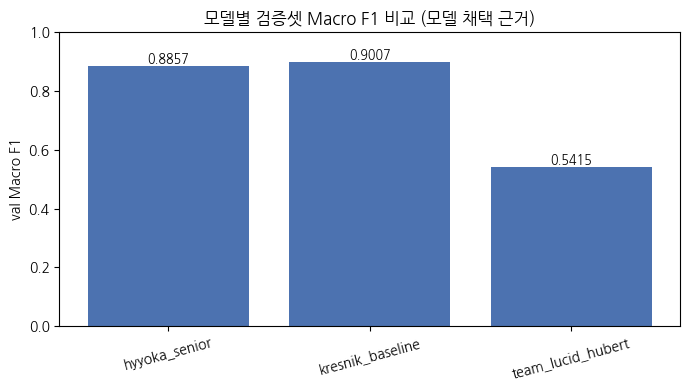

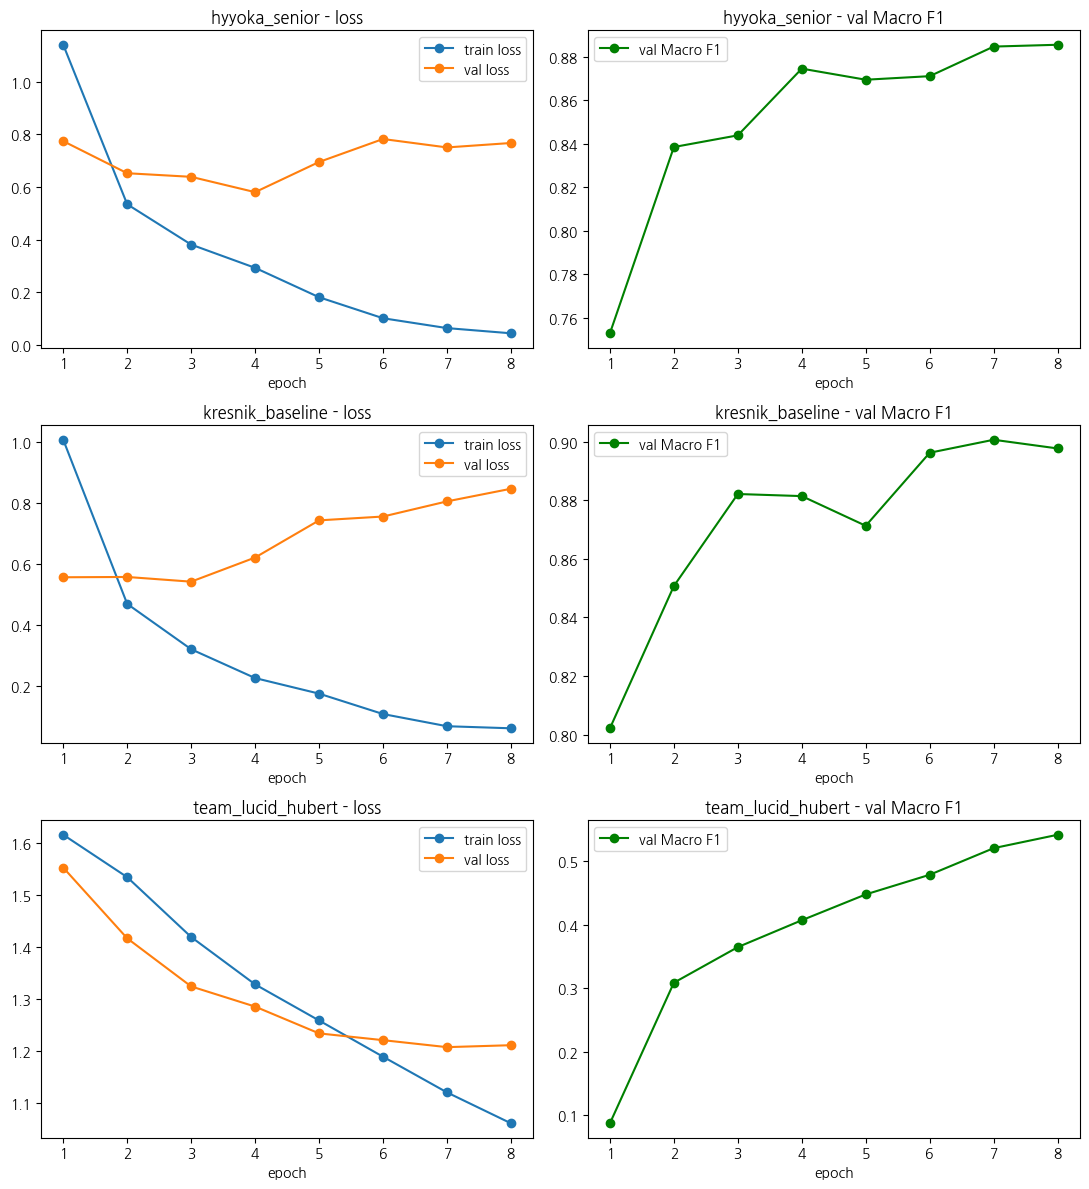

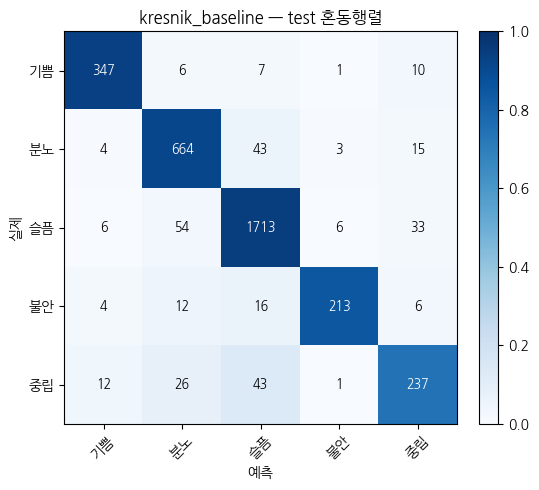

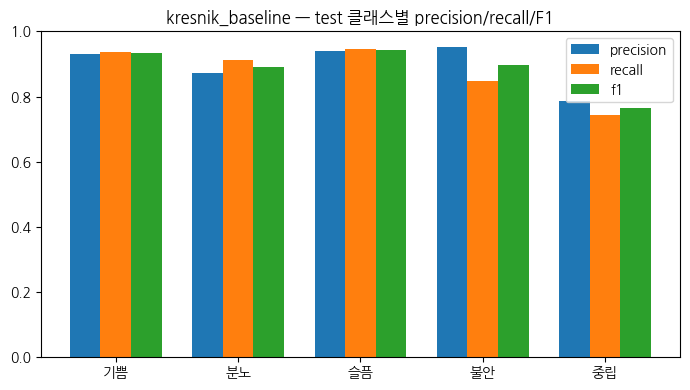

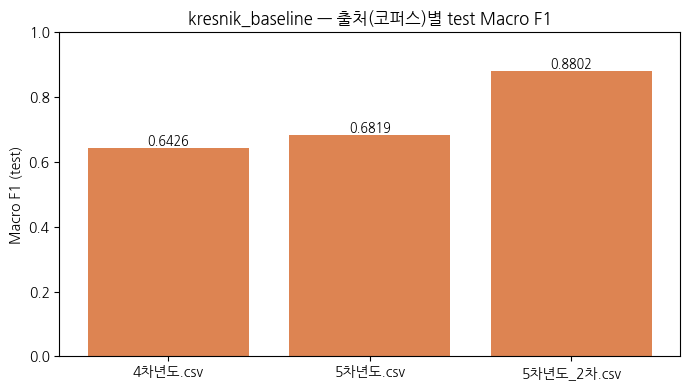

그래프 저장 완료: /content/drive/MyDrive/코랩용 폴더/마음잇다_음성모델/OUTPUT


In [ ]:
GRAPH_DIR = OUTPUT_DIR
os.makedirs(GRAPH_DIR, exist_ok=True)

# ---- 그림1: 모델별 검증셋 Macro F1 비교 ----
model_keys = list(results.keys())
val_f1s = [results[k]["best_val_macro_f1"] for k in model_keys]
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(model_keys, val_f1s, color="#4C72B0")
for b, v in zip(bars, val_f1s):
    ax.text(b.get_x() + b.get_width()/2, v + 0.01, f"{v:.4f}", ha="center", fontsize=9)
ax.set_ylabel("val Macro F1"); ax.set_title("모델별 검증셋 Macro F1 비교 (모델 채택 근거)")
ax.set_ylim(0, 1)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(os.path.join(GRAPH_DIR, "정의서_그림1_모델별_val_MacroF1_비교.png"), dpi=150)
plt.show()

# ---- 그림2: 모델별 학습곡선 ----
fig, axes = plt.subplots(len(model_keys), 2, figsize=(11, 4*len(model_keys)), squeeze=False)
for i, k in enumerate(model_keys):
    hist = results[k]["history"]
    epochs_x = [h["epoch"] for h in hist]
    ax_loss, ax_f1 = axes[i]
    ax_loss.plot(epochs_x, [h["train_loss"] for h in hist], marker="o", label="train loss")
    ax_loss.plot(epochs_x, [h["val_loss"] for h in hist], marker="o", label="val loss")
    ax_loss.set_title(f"{k} - loss"); ax_loss.set_xlabel("epoch"); ax_loss.legend()
    ax_f1.plot(epochs_x, [h["val_macro_f1"] for h in hist], marker="o", color="green", label="val Macro F1")
    ax_f1.set_title(f"{k} - val Macro F1"); ax_f1.set_xlabel("epoch"); ax_f1.legend()
plt.tight_layout()
plt.savefig(os.path.join(GRAPH_DIR, "정의서_그림2_학습곡선.png"), dpi=150)
plt.show()

# ---- 그림3: 최종 채택 모델 test 혼동행렬 ----
cm = confusion_matrix(test_result["labels"], test_result["preds"], labels=list(range(len(LABELS))))
cm_norm = cm / cm.sum(axis=1, keepdims=True)
fig, ax = plt.subplots(figsize=(5.5, 5))
im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(len(LABELS))); ax.set_xticklabels(LABELS, rotation=45)
ax.set_yticks(range(len(LABELS))); ax.set_yticklabels(LABELS)
ax.set_xlabel("예측"); ax.set_ylabel("실제"); ax.set_title(f"{best_model_key} — test 혼동행렬")
for ri in range(len(LABELS)):
    for ci in range(len(LABELS)):
        ax.text(ci, ri, cm[ri, ci], ha="center", va="center",
                 color="white" if cm_norm[ri, ci] > 0.5 else "black", fontsize=9)
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.savefig(os.path.join(GRAPH_DIR, "정의서_그림3_혼동행렬.png"), dpi=150)
plt.show()

# ---- 그림4: 최종 채택 모델 test 클래스별 지표 ----
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(LABELS)); w = 0.25
precisions = [test_result["per_class"][l]["precision"] for l in LABELS]
recalls    = [test_result["per_class"][l]["recall"] for l in LABELS]
f1s        = [test_result["per_class"][l]["f1"] for l in LABELS]
ax.bar(x - w, precisions, w, label="precision")
ax.bar(x, recalls, w, label="recall")
ax.bar(x + w, f1s, w, label="f1")
ax.set_xticks(x); ax.set_xticklabels(LABELS); ax.set_ylim(0, 1)
ax.set_title(f"{best_model_key} — test 클래스별 precision/recall/F1"); ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(GRAPH_DIR, "정의서_그림4_클래스별지표.png"), dpi=150)
plt.show()

# ---- 그림5: 출처(코퍼스)별 test Macro F1 ----
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(source_breakdown["src"].astype(str), source_breakdown["macro_f1"], color="#DD8452")
for i, v in enumerate(source_breakdown["macro_f1"]):
    ax.text(i, v + 0.01, f"{v:.4f}", ha="center", fontsize=9)
ax.set_ylabel("Macro F1 (test)"); ax.set_ylim(0, 1)
ax.set_title(f"{best_model_key} — 출처(코퍼스)별 test Macro F1")
plt.tight_layout()
plt.savefig(os.path.join(GRAPH_DIR, "정의서_그림5_출처별성능.png"), dpi=150)
plt.show()

print("그래프 저장 완료:", GRAPH_DIR)


키인터럽트 후  GPU 초기화

In [ ]:
# import gc, sys

# def free_gpu_memory():
#     ip = get_ipython()
#     if ip is not None:
#         ip.InteractiveTB.tb = None
#     sys.last_traceback = None
#     sys.last_value = None
#     sys.last_type = None

#     for _name in ["model", "smoke_result", "logits", "loss", "inputs", "labels",
#                   "optimizer", "scheduler", "scaler", "criterion", "outputs"]:
#         if _name in globals():
#             del globals()[_name]

#     for _ in range(2):
#         gc.collect()
#         if torch.cuda.is_available():
#             torch.cuda.empty_cache()
#             torch.cuda.ipc_collect()

#     if torch.cuda.is_available():
#         print(f"할당(allocated) {torch.cuda.memory_allocated()/1e9:.2f}GB / 예약(reserved) {torch.cuda.memory_reserved()/1e9:.2f}GB")

# free_gpu_memory()